****Kernel Density Estimation****

**Set Up**

In [16]:
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 25.3 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm

**Problem 1**

a) Sketch ECDF of [1, 1.75, 2, 3, 3.25, 4]

<Axes: ylabel='Proportion'>

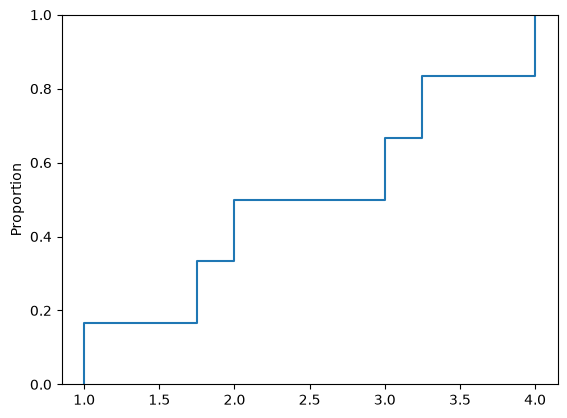

In [2]:
vals = [1, 1.75, 2, 3, 3.25, 4]
sns.ecdfplot(vals)


b) Sketch the uniform KDE with bandwidth h = 0.2

<Axes: ylabel='Density'>

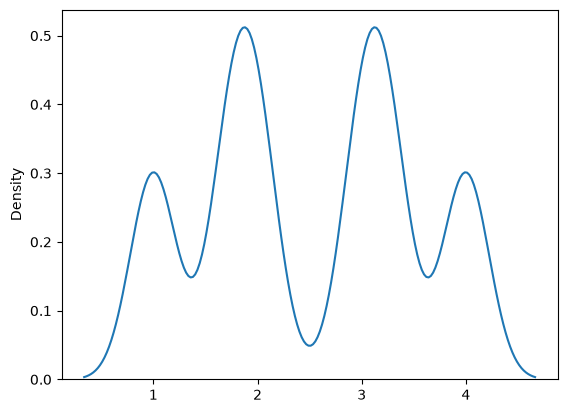

In [3]:
h = 0.2
sns.kdeplot(vals, bw_method = h)

c) Compute Silverman bandwidth

In [4]:
n = len(vals)
stDev = np.std(vals)
Silverman = 1.84*stDev*(n**-0.2)
print(f'Silverman bandwidth: {Silverman}')

Silverman bandwidth: 1.2991670409500977


d) Sketch uniform KDE for Silverman bandwidth

<Axes: ylabel='Density'>

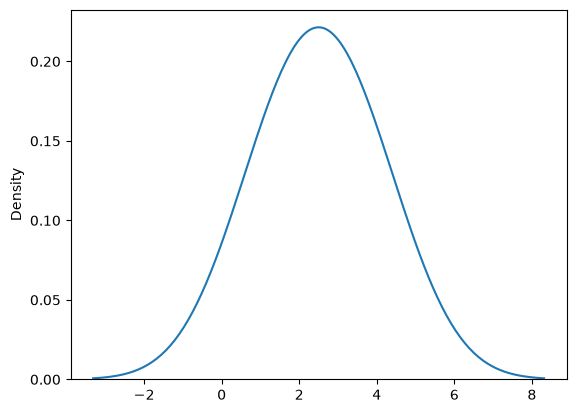

In [5]:
sns.kdeplot(vals, bw_method = Silverman)

e) How are b and d similar or different?

b appears to be overfit compared to d. It has 4 peaks but only measures 6 values, while d has one peak and looks normally distributed (symmetric bell curve). This likely means the initial bandwidth 0.2 was too small, and the larger Silverman bandwidth was a better match for modelling the given data. 

**Problem 2**

X = [-1, -0.5, 0, 0.5, 1]

a) Compute realized KDE at x = 0, f_hat_h(0) with h = 0.6

In [15]:
X = [-1, -0.5, 0, 0.5, 1]
h = 0.6
x = 0
def f_hat_h(x):
    n = len(X)
    count = 0

    for i in X:
        if abs(i - x) < h:
            count += 1

    return count/(2*n*h)

f_hat_h(0)

0.5

b) Compute expectation

In [11]:
x = 0
h = 0.6
expected = (norm.cdf((x+h)) - norm.cdf(x-h))/(2*h)
print(f'The expectation is {expected}')


The expectation is 0.3762448037498774


c) True density

In [12]:
print(f'The true density is {norm.pdf(x)}')

The true density is 0.3989422804014327


d) Are b and c equal? What does this mean about bias?

b = 0.376 and c = 0.399 are not equal, meaning the KDE is a biased estimate at x=0. When an estimate is unbiased, it equals the true statistic it is estimating, which is not the case here. Since we are only checking at one value 0, we cannot generalize and say it is biased for all values, but we can assume based on our result. The bias comes in at the cost of lower variance, and is related to overfitting and underfitting the KDE. When h is small, variance increases while bias decreases because more focus is placed on each value. When h is large, variance decreases while bias increases because the KDE is more smoothed out and less weight is placed on each individual point. 

e) Recompute E[x] at h = 0.1. What happens to the gap between E[x] and f(0) as h shrinks?

The gap skrinks because now the expected value is 0.398 which is very close to the true density of 0.399. 

In [13]:
x = 0
h = 0.1
expected = (norm.cdf((x+h)) - norm.cdf(x-h))/(2*h)
print(f'The expectation is {expected}')

The expectation is 0.3982783727702899


f) Is f_hat_h a consistent estimator? Explain your reasoning.

Yes it is a consistent estimator because it gets closer to the true value as h decreases, which is a consistent pattern. While it may not equal the true density, it still gets close and behaves as expected when more information is included in th analysis (sample size, bandwidth, etc).

g) What are the main considerations in choosing a bandwidth value h?

The main considerations in choosing h is the bias-variance tradeoff and what the goals of the analysis are. If we prefer less variation at the cost of high bias, then the bandwidth should be large. If we prefer less bias at the cost of high variance, then the bandwidth should be small. 

**Problem 3**

X = [5, 7, 7, 8, 10]

a) Compute KDE at x = 6, 6.5, 7, 8, 8.5

In [20]:
X = [5, 7, 7, 8, 10]
x = [6, 6.5, 7, 8, 8.5]
h = 1.5
kdes = []

def f_hat_h(x):
    count = 0
    for i in X:
        if abs(i - x) < h:
            count += 1
    return count/(2*h)

for a in x:
    kdes.append(f_hat_h(a))

list(zip(x, kdes))


[(6, 1.0),
 (6.5, 0.6666666666666666),
 (7, 1.0),
 (8, 1.0),
 (8.5, 0.3333333333333333)]

b) Gaussian KDE

In [24]:
from scipy.stats import gaussian_kde
import math

In [27]:
X = [5, 7, 7, 8, 10]
x = [6, 6.5, 7, 8, 8.5]
h = 1.5

def gaus_kde(h, X, x_i):
    num = []
    for e in X:
        num.append(1/(np.sqrt(2*np.pi)) * math.exp(-(((e-x_i)/h)**2)/2))
    num_sum = sum(num)
    return 1/(n*h) * num_sum

gaus_kde(h, X, 5)

for u in x:
    print(gaus_kde(h, X, u))


0.12597223080742753
0.14054775483533136
0.14837040083493327
0.1395377036261465
0.12550192114934805


c) Biggest jump

The biggest jump in (a) occurs between 8 and 8.5 where the KDE goes from 1 to 0.33. The uniform distribution is discrete while the Gaussian is more continuous, so therefore the jumps are smoother. 

d) Preference

In practice, one might prefer the Gaussian kernel because the variance is lower and it is more interpretable than discrete data. 

**Problem 4**

a) Plot a

In [29]:
df = pd.read_csv("/Users/tiede/Uncertainty/uu_kde/data/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


<Axes: xlabel='ejection_fraction', ylabel='Density'>

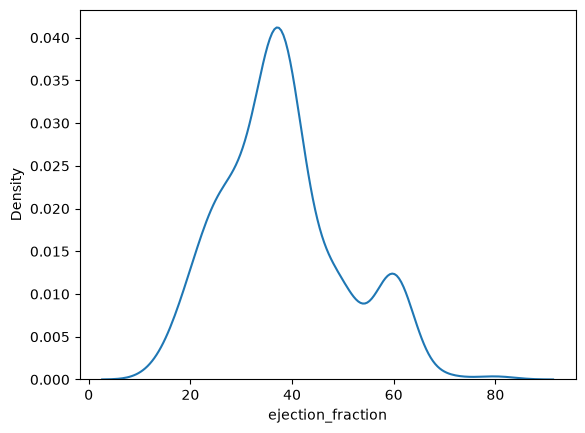

In [30]:
#a.) kernal density estimate of ejection_fraction

sns.kdeplot(data = df, x = "ejection_fraction")

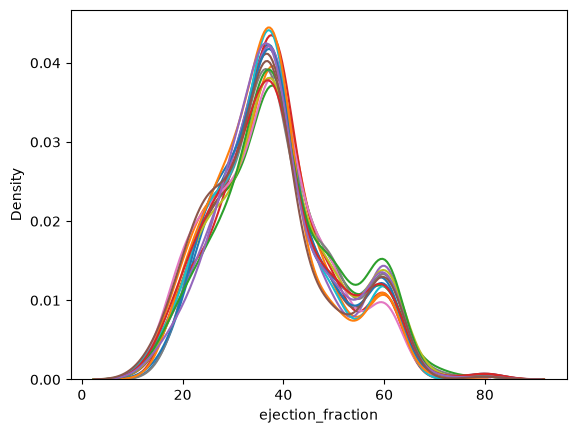

In [32]:
#b. Resample
count = 0
while count < 16:
    sns.kdeplot(df.sample(frac=1.0, replace=True), x="ejection_fraction")
    count += 1

c) For what values is the original plot reliable? For which values is there noticeable variation in your plots of the resampled data?

There is noticeable variation in areas where the estimates change direction at peaks and valleys, but overall are similar after changing direction and are either on the rise or decreasing, especially at around 40-50 of the ejection fraction. 